
# λ₂ multiview dashboard with virtual-lidar $T'$ and animation

This notebook builds a **5-panel animation layout**:

- **Upper left:** one **λ₂ isosurface** colored by vorticity
- **Upper right (split vertically 2:1):**
  - **top:** virtual-lidar **temperature perturbation** curtain $T'(t,z)$
  - **bottom:** $T'(t)$ at one selected altitude, sharing the same time axis
- **Lower left:** one **XZ slice** colored by $T'$ and overlaid with the **λ₂ contour line**
- **Lower right:** one **XY slice** colored by vertical wind $w$ and overlaid with the **λ₂ contour line**

All three 3D panels also show:

- a **thick dashed black vertical line** at the virtual-lidar location,
- **bottom-plane contour lines of** $w$ at the lowest model level,
- the **same camera position**, captured once from the interactive classic 3D view.

## Thermodynamics used here

The notebook assumes the dataset contains:

- `density`
- `theta_total`
- `exner_total`

and computes temperature from the **Poisson/Exner relation**

\[
T = \theta \, \Pi
\]

with `exner_total = Π`. It also computes the implied pressure

\[
p = p_0\, \Pi^{1/\kappa}, \qquad \kappa = R_d / c_p
\]

and, if `density` is available, compares that temperature with the ideal-gas estimate

\[
T_{\mathrm{ideal}} = \frac{p}{\rho R_d}
\]

as a consistency check.

The **temperature perturbation** is defined at every time and level as

\[
T'(t,z,y,x) = T(t,z,y,x) - \langle T(t,z,y,x) \rangle_{x,y}
\]

so the horizontal mean at each `(time, z)` level is removed.


In [32]:

# Optional installs (uncomment if needed)
# %pip install numpy xarray pyvista matplotlib imageio pillow pandas scipy trame jupyterlab


In [33]:

from pathlib import Path

import multiprocessing as mp
import shutil
import sys
import time

import numpy as np
import pandas as pd
import xarray as xr
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import imageio.v2 as imageio
from PIL import Image

import plt_helper

try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None

pv.global_theme.allow_empty_mesh = True


In [34]:

# -----------------------------
# User settings
# -----------------------------
nc_path = Path("/scratch/b/b309199/darwin_240718_400m_diff0/cube.nc")
# nc_path = Path("/scratch/b/b309199/darwin_240718_v200m/cube.nc")
nc_path = Path("/scratch/b/b309199/darwin_240718_400m_blend/cube.nc")
nc_path = Path("/scratch/b/b309199/darwin_240718_400m_schu/cube.nc")

# Variable names in the NetCDF file
u_name = "uvelx"
v_name = "uvely"
w_name = "uvelz"
density_name = "density"
theta_name = "theta_total"
exner_name = "exner_total"

# Coordinate names
time_name = "time"
z_name = "z"
y_name = "y"
x_name = "x"

# Thermodynamic constants
reference_pressure_pa = 100000.0   # 1 bar
rd = 287.05                        # J kg^-1 K^-1
cp = 1004.0                        # J kg^-1 K^-1
kappa = rd / cp

# Which time slice to inspect in the static preview cells
time_index = -1

# Optional downsampling for the 3D rendering (z_stride, y_stride, x_stride)
stride = (1, 1, 1)

# λ2 isosurface controls
negative_lambda2_only = True
single_lambda2_reference_time_index = time_index
single_lambda2_percentile = 5.0
manual_lambda2_level = None
# If manual_lambda2_level is not None, it overrides the percentile-based choice.

# Vorticity coloring controls on the λ2 surface
vorticity_component = None
# None -> color by |ω|, or use "x", "y", or "z"

vorticity_colormap = "plasma"
vorticity_percentile_range = (5.0, 99.5)

# Slice coloring controls
# Lower-left XZ slice now shows T' instead of w.
tprime_colormap = "RdBu_r"
tprime_percentile = 99.0

# Lower-right XY slice stays w.
w_slice_colormap = "RdBu_r"
w_slice_percentile = 99.0
slice_opacity = 1.0

# λ2 contour-line overlay on the slice planes
lambda2_contour_color = "black"
lambda2_contour_width = 4.0

# Bottom-plane w contour lines (all 3D panels)
show_bottom_w_contours = True
bottom_w_contour_count = 10
bottom_w_contour_color = "black"
bottom_w_contour_width = 2.0
bottom_w_contour_opacity = 0.85
exclude_zero_from_bottom_w_contours = True

# Optional smoothing applied to λ2, vorticity, w, and T'
smooth_sigma = 0.0  # e.g. 0.5 or 1.0

# Domain-mean horizontal wind arrow
# Turn on if you want to keep the arrow from earlier notebook versions.
show_mean_wind_arrow = False
mean_wind_arrow_scale = 0.18
mean_wind_min_visible_fraction = 0.08
mean_wind_arrow_color = "white"
mean_wind_arrow_opacity = 1.0

# Virtual lidar location (default: centered)
virtual_lidar_x_index = None  # None -> centered x
virtual_lidar_y_index = 40  # None -> centered y

# Quarter-cut setting for the lower-left panel.
# The two cut planes intersect at the virtual-lidar location.
quarter_cut_removed_corner = "xmin_ymin"  # one of: xmax_ymax, xmax_ymin, xmin_ymax, xmin_ymin

# Altitude used for:
#   - the lower-right XY slice
#   - the lower time-series panel in the upper-right block
#   - the λ2 contour overlay in the XY panel
timeseries_altitude_index = None   # None -> centered altitude
timeseries_altitude_value = 60000   # If not None, nearest z level is used

# T' coloring for the lidar curtain and the XZ slice
tprime_curtain_percentile = 99.0

# 3D dashed lidar line
lidar_line_color = "black"
lidar_line_width = 7
lidar_line_n_dashes = 12
lidar_line_dash_fraction = 0.58

# Dashed guide lines linking the slice panels
slice_reference_line_color = "black"
slice_reference_line_width = 5
slice_reference_line_n_dashes = 14
slice_reference_line_dash_fraction = 0.55


# Scalar bar controls
show_vorticity_scalar_bar_in_classic_view = True
show_tprime_scalar_bar_in_xz_view = True
show_w_scalar_bar_in_xy_view = True

vorticity_scalar_bar_args = dict(
    title_font_size=14,
    label_font_size=12,
    vertical=True,
    position_x=0.86,
    position_y=0.08,
    width=0.08,
    height=0.72,
)

tprime_scalar_bar_args = dict(
    title="T'",
    title_font_size=14,
    label_font_size=12,
    vertical=True,
    position_x=0.86,
    position_y=0.08,
    width=0.08,
    height=0.72,
)

w_scalar_bar_args = dict(
    title=w_name,
    title_font_size=14,
    label_font_size=12,
    vertical=True,
    position_x=0.86,
    position_y=0.08,
    width=0.08,
    height=0.72,
)

# Scene styling
background = "white"
show_outline = True
show_bounds_axes = True
show_axes = False
show_time_label_3d = True

# Time labeling
# If enabled, numeric time values are interpreted as seconds after simulation start.
use_reference_datetime_for_labels = False
reference_datetime = None  # e.g. "2024-07-18 00:00:00"
lidar_time_text_x = 0.02
lidar_time_text_y = 0.96
window_size_3d = (950, 720)

# Combined matplotlib figure size for the 5-panel dashboard
combined_figure_size = (16.0, 12.0)
combined_dpi = 150

# Animation output
frames_dirname = "frames_lambda2_multiview_final"
animation_basename = "lambda2_multiview_final"
animation_format = "mp4"  # "gif" or "mp4"
fps = 6
parallel_frame_generation = True
animation_ncpus = max(1, mp.cpu_count() - 2)
clear_existing_frames = True


In [39]:

def load_time_slice(ds, time_index, stride=(1, 1, 1), extra_var_names=None):
    """Load one time step in (z, y, x) order."""
    z_stride, y_stride, x_stride = stride
    extra_var_names = extra_var_names or []

    x = np.asarray(ds[x_name].values)[::x_stride]
    y = np.asarray(ds[y_name].values)[::y_stride]
    z = np.asarray(ds[z_name].values)[::z_stride]

    arrays = {}
    for name in [u_name, v_name, w_name, *extra_var_names]:
        da = ds[name].isel({time_name: time_index}).transpose(z_name, y_name, x_name).load()
        arrays[name] = np.asarray(da.values)[::z_stride, ::y_stride, ::x_stride]

    return x, y, z, arrays


def compute_temperature_from_theta_exner(theta, exner):
    """Temperature from the standard Exner/Poisson relation: T = theta * Pi."""
    theta = np.asarray(theta, dtype=np.float64)
    exner = np.asarray(exner, dtype=np.float64)
    return theta * exner


def compute_pressure_from_exner(exner, p0=100000.0, rd=287.05, cp=1004.0):
    """Pressure from the Exner function Pi = (p / p0)**kappa, with kappa = Rd/Cp."""
    exner = np.asarray(exner, dtype=np.float64)
    kappa_local = rd / cp
    return p0 * np.power(exner, 1.0 / kappa_local)


def compute_temperature_from_ideal_gas(density, pressure, rd=287.05):
    density = np.asarray(density, dtype=np.float64)
    pressure = np.asarray(pressure, dtype=np.float64)
    return pressure / (density * rd)


def compute_tprime_from_temperature(temperature):
    """Remove the horizontal mean at each vertical level z for one time slice."""
    temperature = np.asarray(temperature, dtype=np.float64)
    mean_xy = np.nanmean(temperature, axis=(1, 2), keepdims=True)
    return temperature - mean_xy


def load_virtual_lidar_tprime(ds, x_index=None, y_index=None):
    """Load a T' time-height curtain for one fixed (x, y) column."""
    nx = int(ds.sizes[x_name])
    ny = int(ds.sizes[y_name])

    if x_index is None:
        x_index = nx // 2
    if y_index is None:
        y_index = ny // 2

    theta = ds[theta_name].transpose(time_name, z_name, y_name, x_name)
    exner = ds[exner_name].transpose(time_name, z_name, y_name, x_name)
    temperature = theta * exner
    tprime = temperature - temperature.mean(dim=(y_name, x_name))

    curtain = (
        tprime
        .isel({y_name: int(y_index), x_name: int(x_index)})
        .load()
    )

    times = np.asarray(ds[time_name].values)
    z = np.asarray(ds[z_name].values)
    x_val = float(np.asarray(ds[x_name].values)[int(x_index)])
    y_val = float(np.asarray(ds[y_name].values)[int(y_index)])

    return (
        times,
        z,
        np.asarray(curtain.values),
        int(x_index),
        int(y_index),
        x_val,
        y_val,
    )


def compute_lambda2_and_vorticity(u, v, w, x, y, z):
    """Compute λ2 and vorticity on a rectilinear grid.

    Array axis order is assumed to be (z, y, x).
    """
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)

    if min(len(x), len(y), len(z)) < 3:
        raise ValueError("Need at least 3 points along x, y, and z to compute gradients.")

    du_dz, du_dy, du_dx = np.gradient(u, z, y, x, edge_order=2)
    dv_dz, dv_dy, dv_dx = np.gradient(v, z, y, x, edge_order=2)
    dw_dz, dw_dy, dw_dx = np.gradient(w, z, y, x, edge_order=2)

    # Symmetric strain tensor S
    Sxx = du_dx
    Syy = dv_dy
    Szz = dw_dz
    Sxy = 0.5 * (du_dy + dv_dx)
    Sxz = 0.5 * (du_dz + dw_dx)
    Syz = 0.5 * (dv_dz + dw_dy)

    # Antisymmetric rotation tensor Ω
    Oxy = 0.5 * (du_dy - dv_dx)
    Oxz = 0.5 * (du_dz - dw_dx)
    Oyz = 0.5 * (dv_dz - dw_dy)

    # Vorticity ω = curl(u)
    vort_x = dw_dy - dv_dz
    vort_y = du_dz - dw_dx
    vort_z = dv_dx - du_dy
    vort_mag = np.sqrt(vort_x**2 + vort_y**2 + vort_z**2)

    if vorticity_component is None:
        vort_scalars = vort_mag
        vort_name = "|ω|"
    elif str(vorticity_component).lower() == "x":
        vort_scalars = vort_x
        vort_name = "ω_x"
    elif str(vorticity_component).lower() == "y":
        vort_scalars = vort_y
        vort_name = "ω_y"
    elif str(vorticity_component).lower() == "z":
        vort_scalars = vort_z
        vort_name = "ω_z"
    else:
        raise ValueError("vorticity_component must be None, 'x', 'y', or 'z'.")

    nz = u.shape[0]
    lambda2 = np.empty_like(u, dtype=np.float64)

    # Chunk over z to reduce peak memory usage.
    chunk_size_z = max(1, min(nz, 12))
    for z0 in range(0, nz, chunk_size_z):
        z1 = min(z0 + chunk_size_z, nz)
        sl = slice(z0, z1)

        S = np.zeros((z1 - z0, u.shape[1], u.shape[2], 3, 3), dtype=np.float64)
        O = np.zeros_like(S)

        S[..., 0, 0] = Sxx[sl]
        S[..., 1, 1] = Syy[sl]
        S[..., 2, 2] = Szz[sl]
        S[..., 0, 1] = S[..., 1, 0] = Sxy[sl]
        S[..., 0, 2] = S[..., 2, 0] = Sxz[sl]
        S[..., 1, 2] = S[..., 2, 1] = Syz[sl]

        O[..., 0, 1] = Oxy[sl]
        O[..., 1, 0] = -Oxy[sl]
        O[..., 0, 2] = Oxz[sl]
        O[..., 2, 0] = -Oxz[sl]
        O[..., 1, 2] = Oyz[sl]
        O[..., 2, 1] = -Oyz[sl]

        M = S @ S + O @ O
        eigvals = np.linalg.eigvalsh(M)
        lambda2[sl] = eigvals[..., 1]

    return lambda2, vort_scalars, vort_mag, (vort_x, vort_y, vort_z), vort_name


def build_structured_grid(x, y, z, point_arrays, active_scalar_name):
    """Build a PyVista StructuredGrid from 1D coordinates and point arrays."""
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    grid = pv.StructuredGrid(X, Y, Z)

    expected_shape = (len(z), len(y), len(x))
    for name, arr in point_arrays.items():
        arr = np.asarray(arr)
        if arr.shape != expected_shape:
            raise ValueError(f"Array {name!r} has shape {arr.shape}, expected {expected_shape}")
        arr_xyz = np.transpose(arr, (2, 1, 0))
        grid.point_data[name] = arr_xyz.ravel(order="F")

    grid.set_active_scalars(active_scalar_name)
    return grid


def choose_single_lambda2_level(lambda2, negative_only=True, percentile=5.0, manual_level=None):
    """Choose one λ2 contour level.

    More negative values tend to isolate stronger cores.
    """
    if manual_level is not None:
        return float(manual_level)

    vals = np.asarray(lambda2)
    vals = vals[np.isfinite(vals)]

    if negative_only:
        vals = vals[vals < 0]
        if vals.size == 0:
            raise ValueError("No negative λ2 values found. Try negative_lambda2_only = False.")

    if not (0 <= percentile <= 100):
        raise ValueError("single_lambda2_percentile must be between 0 and 100.")

    return float(np.percentile(vals, percentile))


def choose_clim(data, percentile_range):
    vals = np.asarray(data)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("No finite values found.")
    p_lo, p_hi = percentile_range
    vmin, vmax = np.percentile(vals, [p_lo, p_hi])
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError("Could not determine finite color limits.")
    if vmin == vmax:
        vmax = vmin + 1e-12
    return float(vmin), float(vmax)


def choose_symmetric_clim(data, percentile=99.0):
    vals = np.asarray(data)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("No finite values found.")
    vmax = float(np.percentile(np.abs(vals), percentile))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = float(np.nanmax(np.abs(vals)))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1e-12
    return -vmax, vmax


def choose_symmetric_contour_levels(clim, count=10, exclude_zero=True):
    count = max(1, int(count))
    vmax = max(abs(float(clim[0])), abs(float(clim[1])))
    levels = np.linspace(-vmax, vmax, count + 2)
    if exclude_zero:
        levels = levels[np.abs(levels) > 1e-12]
    return np.asarray(levels, dtype=float)


def choose_altitude(z_values, altitude_index=None, altitude_value=None):
    z_values = np.asarray(z_values, dtype=float)
    if altitude_value is not None:
        idx = int(np.nanargmin(np.abs(z_values - float(altitude_value))))
    else:
        if altitude_index is None:
            idx = len(z_values) // 2
        else:
            idx = int(np.clip(int(altitude_index), 0, len(z_values) - 1))
    return idx, float(z_values[idx])


def get_quarter_cut_geometry(x, y, z, x_cut_value, y_cut_value, removed_corner="xmax_ymax"):
    """Return clipping bounds and half-plane keeps for a quarter-cut view."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    xmin, xmax = float(np.nanmin(x)), float(np.nanmax(x))
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    zmin, zmax = float(np.nanmin(z)), float(np.nanmax(z))
    x_cut = float(x_cut_value)
    y_cut = float(y_cut_value)

    if removed_corner == "xmax_ymax":
        remove_bounds = (x_cut, xmax, y_cut, ymax, zmin, zmax)
        yz_keep = ("y", y_cut, False)  # keep y >= y_cut on the x=x_cut slice
        xz_keep = ("x", x_cut, False)  # keep x >= x_cut on the y=y_cut slice
    elif removed_corner == "xmax_ymin":
        remove_bounds = (x_cut, xmax, ymin, y_cut, zmin, zmax)
        yz_keep = ("y", y_cut, True)   # keep y <= y_cut
        xz_keep = ("x", x_cut, False)  # keep x >= x_cut
    elif removed_corner == "xmin_ymax":
        remove_bounds = (xmin, x_cut, y_cut, ymax, zmin, zmax)
        yz_keep = ("y", y_cut, False)  # keep y >= y_cut
        xz_keep = ("x", x_cut, True)   # keep x <= x_cut
    elif removed_corner == "xmin_ymin":
        remove_bounds = (xmin, x_cut, ymin, y_cut, zmin, zmax)
        yz_keep = ("y", y_cut, True)   # keep y <= y_cut
        xz_keep = ("x", x_cut, True)   # keep x <= x_cut
    else:
        raise ValueError("quarter_cut_removed_corner must be one of: xmax_ymax, xmax_ymin, xmin_ymax, xmin_ymin")

    return {
        "x_cut": x_cut,
        "y_cut": y_cut,
        "remove_bounds": tuple(float(v) for v in remove_bounds),
        "yz_keep": yz_keep,
        "xz_keep": xz_keep,
    }


def clip_slice_to_exposed_halfplane(slice_mesh, axis, value, invert):
    """Clip a cut-plane mesh or line set to the exposed half-plane."""
    if slice_mesh is None or slice_mesh.n_points == 0:
        return slice_mesh

    xmid, ymid, zmid = slice_mesh.center
    if axis == "x":
        origin = (float(value), float(ymid), float(zmid))
        return slice_mesh.clip(normal="x", origin=origin, invert=bool(invert))
    elif axis == "y":
        origin = (float(xmid), float(value), float(zmid))
        return slice_mesh.clip(normal="y", origin=origin, invert=bool(invert))
    else:
        raise ValueError("axis must be 'x' or 'y'")


def compute_elapsed_seconds(value, time_start_value):
    value_arr = np.asarray(value)
    start_arr = np.asarray(time_start_value)

    if np.issubdtype(value_arr.dtype, np.datetime64) or np.issubdtype(start_arr.dtype, np.datetime64):
        value_ns = value_arr.astype("datetime64[ns]")
        start_ns = start_arr.astype("datetime64[ns]")
        return np.asarray((value_ns - start_ns) / np.timedelta64(1, "s"), dtype=np.float64)

    return np.asarray(value_arr, dtype=np.float64) - float(start_arr)


def format_elapsed_hms(total_seconds):
    total_seconds = max(0, int(np.rint(float(total_seconds))))
    hrs = total_seconds // 3600
    mins = (total_seconds % 3600) // 60
    secs = total_seconds % 60
    return f"{hrs:02d}:{mins:02d}:{secs:02d}"


def format_reference_timestamp(elapsed_seconds):
    if not use_reference_datetime_for_labels or reference_datetime is None:
        return None

    ts = pd.to_datetime(reference_datetime) + pd.to_timedelta(float(elapsed_seconds), unit="s")
    return ts.strftime("%Y-%m-%d %H:%M:%S")


def format_time_value(value, time_start_value, frame_index=None):
    elapsed_seconds = float(np.asarray(compute_elapsed_seconds(value, time_start_value)).reshape(-1)[0])
    label = f"Time: {format_elapsed_hms(elapsed_seconds)}s"
    if frame_index is not None:
        label += f" ({int(frame_index):03d})"

    reference_label = format_reference_timestamp(elapsed_seconds)
    if reference_label is not None:
        label = f"{label}\n{reference_label}"
    return label


def format_elapsed_tick_label(value, pos=None):
    return format_elapsed_hms(value)


def apply_rotated_default_camera(plotter):
    """Use PyVista's default isometric view, rotated 180 degrees around z."""
    plotter.view_isometric()
    focal_point = np.asarray(plotter.camera.focal_point, dtype=float)
    position = np.asarray(plotter.camera.position, dtype=float)
    view_up = tuple(np.asarray(plotter.camera.up, dtype=float))

    rel = position - focal_point
    rel[0] *= -1.0
    rel[1] *= -1.0

    plotter.camera_position = [
        tuple(focal_point + rel),
        tuple(focal_point),
        view_up,
    ]


def add_mean_wind_arrow(plotter, x, y, z, u, v):
    """Add one domain-mean horizontal wind arrow on the bottom face."""
    if not show_mean_wind_arrow:
        return

    u_mean = float(np.nanmean(u))
    v_mean = float(np.nanmean(v))
    mean_hvec = np.array([u_mean, v_mean, 0.0], dtype=float)
    mean_hspeed = float(np.linalg.norm(mean_hvec[:2]))
    if mean_hspeed <= 0 or not np.isfinite(mean_hspeed):
        return

    x_mid = float(0.5 * (np.nanmin(x) + np.nanmax(x)))
    y_mid = float(0.5 * (np.nanmin(y) + np.nanmax(y)))
    z0 = float(np.nanmin(z))
    origin = np.array([x_mid, y_mid, z0], dtype=float)

    x_span = float(np.nanmax(x) - np.nanmin(x))
    y_span = float(np.nanmax(y) - np.nanmin(y))
    horizontal_span = max(np.hypot(x_span, y_span), 1e-12)

    local_hspeed = np.sqrt(u**2 + v**2)
    characteristic_speed = float(np.nanpercentile(local_hspeed, 95))
    if not np.isfinite(characteristic_speed) or characteristic_speed <= 0:
        characteristic_speed = mean_hspeed

    direction = mean_hvec / mean_hspeed
    scaled_length = horizontal_span * mean_wind_arrow_scale * (mean_hspeed / characteristic_speed)
    min_length = horizontal_span * mean_wind_min_visible_fraction
    arrow_length = max(scaled_length, min_length)

    arrow = pv.Arrow(
        start=origin,
        direction=direction,
        scale=arrow_length,
        tip_length=0.22,
        tip_radius=0.05,
        shaft_radius=0.018,
    )
    plotter.add_mesh(
        arrow,
        color=mean_wind_arrow_color,
        opacity=mean_wind_arrow_opacity,
    )


def make_dashed_line_segments(p0, p1, n_dashes=12, dash_fraction=0.58):
    """Return point pairs for a dashed 3D line, suitable for plotter.add_lines()."""
    p0 = np.asarray(p0, dtype=float).reshape(3)
    p1 = np.asarray(p1, dtype=float).reshape(3)
    n_dashes = max(1, int(n_dashes))
    dash_fraction = float(np.clip(dash_fraction, 0.05, 0.95))

    edges = np.linspace(0.0, 1.0, n_dashes + 1)
    pts = []
    direction = p1 - p0
    for ta, tb in zip(edges[:-1], edges[1:]):
        tend = ta + dash_fraction * (tb - ta)
        pts.append(p0 + ta * direction)
        pts.append(p0 + tend * direction)

    return np.asarray(pts, dtype=float)


def make_dashed_vertical_segments(x0, y0, zmin, zmax, n_dashes=12, dash_fraction=0.58):
    """Return point pairs for a dashed vertical line, suitable for plotter.add_lines()."""
    return make_dashed_line_segments(
        [float(x0), float(y0), float(zmin)],
        [float(x0), float(y0), float(zmax)],
        n_dashes=n_dashes,
        dash_fraction=dash_fraction,
    )


def add_virtual_lidar_line(plotter, x0, y0, zmin, zmax):
    segments = make_dashed_vertical_segments(
        x0=x0,
        y0=y0,
        zmin=zmin,
        zmax=zmax,
        n_dashes=lidar_line_n_dashes,
        dash_fraction=lidar_line_dash_fraction,
    )
    plotter.add_lines(segments, color=lidar_line_color, width=lidar_line_width)


def add_dashed_reference_line(plotter, p0, p1, color=None, width=None, n_dashes=None, dash_fraction=None):
    """Add a dashed guide line between two 3D points."""
    segments = make_dashed_line_segments(
        p0,
        p1,
        n_dashes=slice_reference_line_n_dashes if n_dashes is None else n_dashes,
        dash_fraction=slice_reference_line_dash_fraction if dash_fraction is None else dash_fraction,
    )
    plotter.add_lines(
        segments,
        color=slice_reference_line_color if color is None else color,
        width=slice_reference_line_width if width is None else width,
    )


def prepare_scene_data_for_time(ds, time_index, lambda2_level, stride=(1, 1, 1)):
    """Compute all fields and meshes needed for a given time index."""
    x, y, z, arrays = load_time_slice(
        ds,
        time_index=time_index,
        stride=stride,
        extra_var_names=[density_name, theta_name, exner_name],
    )

    u = np.asarray(arrays[u_name], dtype=np.float64)
    v = np.asarray(arrays[v_name], dtype=np.float64)
    w = np.asarray(arrays[w_name], dtype=np.float64)
    density = np.asarray(arrays[density_name], dtype=np.float64)
    theta = np.asarray(arrays[theta_name], dtype=np.float64)
    exner = np.asarray(arrays[exner_name], dtype=np.float64)

    temperature = compute_temperature_from_theta_exner(theta, exner)
    tprime = compute_tprime_from_temperature(temperature)

    lambda2, vort_scalars, vort_mag, vort_vector, vort_name = compute_lambda2_and_vorticity(
        u=u,
        v=v,
        w=w,
        x=x,
        y=y,
        z=z,
    )

    if smooth_sigma and smooth_sigma > 0:
        if gaussian_filter is None:
            raise ImportError("scipy is required for smoothing; install scipy or set smooth_sigma = 0")
        lambda2 = gaussian_filter(lambda2, sigma=smooth_sigma)
        vort_scalars = gaussian_filter(vort_scalars, sigma=smooth_sigma)
        vort_mag = gaussian_filter(vort_mag, sigma=smooth_sigma)
        w = gaussian_filter(w, sigma=smooth_sigma)
        tprime = gaussian_filter(tprime, sigma=smooth_sigma)

    point_arrays = {
        "lambda2": lambda2,
        "vorticity_scalar": vort_scalars,
        "vorticity_magnitude": vort_mag,
        "w": w,
        "tprime": tprime,
        "temperature": temperature,
        "density": density,
        "theta": theta,
        "exner": exner,
    }
    grid = build_structured_grid(x, y, z, point_arrays=point_arrays, active_scalar_name="lambda2")

    surface = grid.contour(isosurfaces=[float(lambda2_level)], scalars="lambda2")

    return {
        "x": x,
        "y": y,
        "z": z,
        "u": u,
        "v": v,
        "w": w,
        "tprime": tprime,
        "temperature": temperature,
        "density": density,
        "theta": theta,
        "exner": exner,
        "lambda2": lambda2,
        "grid": grid,
        "surface": surface,
        "vorticity_name": vort_name,
        "vorticity_vector": vort_vector,
    }


def build_bottom_w_contours(x, y, z, w_field, contour_levels):
    """Build bottom-plane w contour lines from the actual lowest model level.

    Using an explicit bottom-face mesh is more robust than slicing exactly at the
    domain boundary z = z_min, where plane slicing can return no geometry.
    """
    if not show_bottom_w_contours:
        return None
    if contour_levels is None or len(contour_levels) == 0:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    w_field = np.asarray(w_field, dtype=float)

    if w_field.ndim != 3 or w_field.shape[0] < 1:
        return None

    # Lowest model level on the bottom face
    w0 = w_field[0]  # shape (ny, nx)

    Xb, Yb = np.meshgrid(x, y, indexing="ij")
    Zb = np.full_like(Xb, float(np.min(z)))
    bottom = pv.StructuredGrid(Xb, Yb, Zb)
    bottom.point_data["w"] = np.asarray(w0.T, dtype=float).ravel(order="F")

    vals = np.asarray(bottom.point_data["w"])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None

    lo = float(np.min(vals))
    hi = float(np.max(vals))
    levels = np.asarray(contour_levels, dtype=float)
    levels = levels[(levels >= lo) & (levels <= hi)]
    if levels.size == 0:
        return None

    lines = bottom.contour(isosurfaces=levels, scalars="w")
    if lines.n_points == 0:
        return None
    return lines


def build_lambda2_slice_contours_from_surface(surface, normal, origin):
    """Intersect the already-extracted λ2 isosurface with a slice plane.

    This is more reliable than re-contouring the 2D slice mesh and guarantees
    that the overlay corresponds exactly to the plotted λ2 isosurface level.
    """
    if surface is None or surface.n_points == 0:
        return None

    lines = surface.slice(normal=normal, origin=origin)
    if lines.n_points == 0:
        return None
    return lines


def populate_plotter_variant(
    plotter,
    scene_data,
    variant,
    camera_position,
    lambda2_level,
    vorticity_clim,
    tprime_clim,
    w_clim,
    bottom_w_contour_levels,
    lidar_x_val,
    lidar_y_val,
    slice_z_val,
    show_time_label=False,
    time_label_text=None,
):
    """Populate one PyVista plotter for one of the three 3D panel variants."""
    plotter.clear()
    plotter.set_background(background)

    x = scene_data["x"]
    y = scene_data["y"]
    z = scene_data["z"]
    u = scene_data["u"]
    v = scene_data["v"]
    grid = scene_data["grid"]
    surface = scene_data["surface"]
    w = scene_data["w"]
    vort_name = scene_data["vorticity_name"]

    if show_outline:
        plotter.add_mesh(grid.outline(), color="black", line_width=1)

    if variant == "classic":
        if surface.n_points > 0:
            sb_args = dict(vorticity_scalar_bar_args)
            sb_args["title"] = vort_name
            plotter.add_mesh(
                surface,
                scalars="vorticity_scalar",
                cmap=vorticity_colormap,
                clim=vorticity_clim,
                opacity=1.0,
                smooth_shading=True,
                show_scalar_bar=show_vorticity_scalar_bar_in_classic_view,
                scalar_bar_args=sb_args,
            )

    elif variant == "xz_slice":
        if lidar_x_val is None or lidar_y_val is None:
            raise ValueError("lidar_x_val and lidar_y_val are required for the lower-left quarter-cut variant.")

        cut = get_quarter_cut_geometry(
            x=x,
            y=y,
            z=z,
            x_cut_value=float(lidar_x_val),
            y_cut_value=float(lidar_y_val),
            removed_corner=quarter_cut_removed_corner,
        )

        surface_cut = surface
        if surface_cut is not None and surface_cut.n_points > 0:
            surface_cut = surface_cut.clip_box(cut["remove_bounds"], invert=True)
            if surface_cut.n_points > 0:
                plotter.add_mesh(
                    surface_cut,
                    scalars="vorticity_scalar",
                    cmap=vorticity_colormap,
                    clim=vorticity_clim,
                    opacity=1.0,
                    smooth_shading=True,
                    show_scalar_bar=False,
                )

        yz_slice = grid.slice(
            normal="x",
            origin=(float(lidar_x_val), float(np.mean(y)), float(np.mean(z))),
        )
        yz_axis, yz_value, yz_invert = cut["yz_keep"]
        yz_slice = clip_slice_to_exposed_halfplane(yz_slice, yz_axis, yz_value, yz_invert)

        xz_slice = grid.slice(
            normal="y",
            origin=(float(np.mean(x)), float(lidar_y_val), float(np.mean(z))),
        )
        xz_axis, xz_value, xz_invert = cut["xz_keep"]
        xz_slice = clip_slice_to_exposed_halfplane(xz_slice, xz_axis, xz_value, xz_invert)

        scalar_bar_drawn = False
        for cut_slice in (yz_slice, xz_slice):
            if cut_slice is not None and cut_slice.n_points > 0:
                plotter.add_mesh(
                    cut_slice,
                    scalars="tprime",
                    cmap=tprime_colormap,
                    clim=tprime_clim,
                    opacity=float(slice_opacity),
                    smooth_shading=False,
                    show_scalar_bar=(show_tprime_scalar_bar_in_xz_view and not scalar_bar_drawn),
                    scalar_bar_args=dict(tprime_scalar_bar_args),
                )
                scalar_bar_drawn = True

        yz_lines = build_lambda2_slice_contours_from_surface(
            surface,
            normal="x",
            origin=(float(lidar_x_val), float(np.mean(y)), float(np.mean(z))),
        )
        yz_lines = clip_slice_to_exposed_halfplane(yz_lines, yz_axis, yz_value, yz_invert)
        if yz_lines is not None and yz_lines.n_points > 0:
            plotter.add_mesh(
                yz_lines,
                color=lambda2_contour_color,
                line_width=lambda2_contour_width,
                render_lines_as_tubes=False,
            )

        xz_lines = build_lambda2_slice_contours_from_surface(
            surface,
            normal="y",
            origin=(float(np.mean(x)), float(lidar_y_val), float(np.mean(z))),
        )
        xz_lines = clip_slice_to_exposed_halfplane(xz_lines, xz_axis, xz_value, xz_invert)
        if xz_lines is not None and xz_lines.n_points > 0:
            plotter.add_mesh(
                xz_lines,
                color=lambda2_contour_color,
                line_width=lambda2_contour_width,
                render_lines_as_tubes=False,
            )

        # Cross-reference guide lines: show the horizontal altitude of the XY slice on both vertical cut planes.
        if slice_z_val is not None:
            yz_ref = pv.PolyData(
                make_dashed_line_segments(
                    [float(lidar_x_val), float(np.nanmin(y)), float(slice_z_val)],
                    [float(lidar_x_val), float(np.nanmax(y)), float(slice_z_val)],
                    n_dashes=slice_reference_line_n_dashes,
                    dash_fraction=slice_reference_line_dash_fraction,
                )
            )
            yz_ref = clip_slice_to_exposed_halfplane(yz_ref, yz_axis, yz_value, yz_invert)
            if yz_ref is not None and yz_ref.n_points > 0:
                plotter.add_mesh(
                    yz_ref,
                    color=slice_reference_line_color,
                    line_width=slice_reference_line_width,
                    render_lines_as_tubes=False,
                )

            xz_ref = pv.PolyData(
                make_dashed_line_segments(
                    [float(np.nanmin(x)), float(lidar_y_val), float(slice_z_val)],
                    [float(np.nanmax(x)), float(lidar_y_val), float(slice_z_val)],
                    n_dashes=slice_reference_line_n_dashes,
                    dash_fraction=slice_reference_line_dash_fraction,
                )
            )
            xz_ref = clip_slice_to_exposed_halfplane(xz_ref, xz_axis, xz_value, xz_invert)
            if xz_ref is not None and xz_ref.n_points > 0:
                plotter.add_mesh(
                    xz_ref,
                    color=slice_reference_line_color,
                    line_width=slice_reference_line_width,
                    render_lines_as_tubes=False,
                )

    elif variant == "xy_slice":
        if slice_z_val is None:
            raise ValueError("slice_z_val is required for the xy_slice variant.")
        slice_mesh = grid.slice(
            normal="z",
            origin=(float(np.mean(x)), float(np.mean(y)), float(slice_z_val)),
        )
        if slice_mesh.n_points > 0:
            plotter.add_mesh(
                slice_mesh,
                scalars="w",
                cmap=w_slice_colormap,
                clim=w_clim,
                opacity=float(slice_opacity),
                smooth_shading=False,
                show_scalar_bar=show_w_scalar_bar_in_xy_view,
                scalar_bar_args=dict(w_scalar_bar_args),
            )
            lambda2_lines = build_lambda2_slice_contours_from_surface(
                surface,
                normal="z",
                origin=(float(np.mean(x)), float(np.mean(y)), float(slice_z_val)),
            )
            if lambda2_lines is not None:
                plotter.add_mesh(
                    lambda2_lines,
                    color=lambda2_contour_color,
                    line_width=lambda2_contour_width,
                    render_lines_as_tubes=False,
                )
            if lidar_x_val is not None and lidar_y_val is not None:
                x_ref = pv.PolyData(
                    make_dashed_line_segments(
                        [float(lidar_x_val), float(np.nanmin(y)), float(slice_z_val)],
                        [float(lidar_x_val), float(np.nanmax(y)), float(slice_z_val)],
                        n_dashes=slice_reference_line_n_dashes,
                        dash_fraction=slice_reference_line_dash_fraction,
                    )
                )
                y_ref = pv.PolyData(
                    make_dashed_line_segments(
                        [float(np.nanmin(x)), float(lidar_y_val), float(slice_z_val)],
                        [float(np.nanmax(x)), float(lidar_y_val), float(slice_z_val)],
                        n_dashes=slice_reference_line_n_dashes,
                        dash_fraction=slice_reference_line_dash_fraction,
                    )
                )
                plotter.add_mesh(
                    x_ref,
                    color=slice_reference_line_color,
                    line_width=slice_reference_line_width,
                    render_lines_as_tubes=False,
                )
                plotter.add_mesh(
                    y_ref,
                    color=slice_reference_line_color,
                    line_width=slice_reference_line_width,
                    render_lines_as_tubes=False,
                )
    else:
        raise ValueError("variant must be 'classic', 'xz_slice', or 'xy_slice'.")

    bottom_w_lines = build_bottom_w_contours(x, y, z, w_field=w, contour_levels=bottom_w_contour_levels)
    if bottom_w_lines is not None:
        plotter.add_mesh(
            bottom_w_lines,
            color=bottom_w_contour_color,
            line_width=bottom_w_contour_width,
            opacity=bottom_w_contour_opacity,
            render_lines_as_tubes=False,
        )

    add_mean_wind_arrow(plotter, x, y, z, u, v)

    if lidar_x_val is not None and lidar_y_val is not None:
        add_virtual_lidar_line(
            plotter,
            x0=float(lidar_x_val),
            y0=float(lidar_y_val),
            zmin=float(np.nanmin(z)),
            zmax=float(np.nanmax(z)),
        )

    if show_bounds_axes:
        plotter.show_bounds(
            grid="back",
            location="outer",
            xtitle="",
            ytitle="",
            ztitle="",
            n_xlabels=5,
            n_ylabels=5,
            n_zlabels=5,
            font_size=12,
        )

    if show_axes:
        plotter.show_axes()

    plotter.add_bounding_box(color="black")

    if show_time_label and time_label_text is not None:
        plotter.add_text(
            time_label_text,
            position="upper_left",
            font_size=11,
            color="black",
        )

    if camera_position is not None:
        plotter.camera_position = camera_position
    else:
        apply_rotated_default_camera(plotter)


def render_pyvista_variant_frame(
    plotter,
    scene_data,
    variant,
    camera_position,
    lambda2_level,
    vorticity_clim,
    tprime_clim,
    w_clim,
    bottom_w_contour_levels,
    lidar_x_val,
    lidar_y_val,
    slice_z_val,
    time_label_text,
):
    populate_plotter_variant(
        plotter=plotter,
        scene_data=scene_data,
        variant=variant,
        camera_position=camera_position,
        lambda2_level=lambda2_level,
        vorticity_clim=vorticity_clim,
        tprime_clim=tprime_clim,
        w_clim=w_clim,
        bottom_w_contour_levels=bottom_w_contour_levels,
        lidar_x_val=lidar_x_val,
        lidar_y_val=lidar_y_val,
        slice_z_val=slice_z_val,
        show_time_label=show_time_label_3d,
        time_label_text=time_label_text,
    )
    return plotter.screenshot(filename=None, return_img=True)


def plot_virtual_lidar_panels(
    ax_curtain,
    ax_series,
    times,
    z,
    tprime_curtain,
    current_time_value,
    selected_altitude_value,
    tprime_clim,
    frame_index=None,
    x_val=None,
    y_val=None,
):
    """Draw the time-height T' curtain and the single-altitude T' time series."""
    times = np.asarray(times)
    z = np.asarray(z)
    curtain = np.asarray(tprime_curtain)

    if curtain.ndim != 2:
        raise ValueError("tprime_curtain must have shape (nt, nz)")

    altitude_idx = int(np.nanargmin(np.abs(z - float(selected_altitude_value))))
    tprime_series = curtain[:, altitude_idx]

    time_start_value = times[0]
    x_vals = np.asarray(compute_elapsed_seconds(times, time_start_value), dtype=np.float64)
    current_x = float(np.asarray(compute_elapsed_seconds(current_time_value, time_start_value)).reshape(-1)[0])

    mesh = ax_curtain.pcolormesh(
        x_vals,
        z,
        curtain.T,
        shading="auto",
        cmap=tprime_colormap,
        vmin=tprime_clim[0],
        vmax=tprime_clim[1],
    )
    formatter = mticker.FuncFormatter(format_elapsed_tick_label)
    ax_curtain.xaxis.set_major_formatter(formatter)
    ax_series.xaxis.set_major_formatter(formatter)

    ax_curtain.axvline(current_x, linestyle="--", linewidth=1.8, color="black")
    ax_curtain.axhline(float(selected_altitude_value), linestyle="--", linewidth=1.4, color="black", alpha=0.85)
    ax_curtain.set_ylabel(z_name)
    ax_curtain.text(
        lidar_time_text_x,
        lidar_time_text_y,
        format_time_value(current_time_value, time_start_value, frame_index=frame_index),
        transform=ax_curtain.transAxes,
        weight="bold",
        ha="left",
        va="top",
        bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"},
    )
    ax_curtain.grid(True, alpha=0.22)
    plt.setp(ax_curtain.get_xticklabels(), visible=False)

    ax_series.plot(x_vals, tprime_series, linewidth=1.8, color="black")
    ax_series.axvline(current_x, linestyle="--", linewidth=1.8, color="black")
    ax_series.set_xlabel("Time since start")
    ax_series.set_ylabel("T'")
    ax_series.grid(True, alpha=0.28)

    return mesh


def render_combined_frame(
    plotters,
    ds,
    time_index,
    lambda2_level,
    vorticity_clim,
    tprime_clim,
    w_clim,
    bottom_w_contour_levels,
    times_lidar,
    z_lidar,
    tprime_curtain,
    camera_position,
    lidar_x_val,
    lidar_y_val,
    selected_altitude_value,
    figure_size=(16.0, 12.0),
    dpi=150,
):
    """Render the 5-panel combined frame."""
    scene_data = prepare_scene_data_for_time(
        ds=ds,
        time_index=time_index,
        lambda2_level=lambda2_level,
        stride=stride,
    )
    time_values = np.asarray(ds[time_name].values)
    time_start_value = time_values[0]
    current_time_value = time_values[int(time_index)]
    time_label_text = format_time_value(current_time_value, time_start_value)

    img_classic = render_pyvista_variant_frame(
        plotter=plotters["classic"],
        scene_data=scene_data,
        variant="classic",
        camera_position=camera_position,
        lambda2_level=lambda2_level,
        vorticity_clim=vorticity_clim,
        tprime_clim=tprime_clim,
        w_clim=w_clim,
        bottom_w_contour_levels=bottom_w_contour_levels,
        lidar_x_val=lidar_x_val,
        lidar_y_val=lidar_y_val,
        slice_z_val=selected_altitude_value,
        time_label_text=time_label_text,
    )
    img_xz = render_pyvista_variant_frame(
        plotter=plotters["xz_slice"],
        scene_data=scene_data,
        variant="xz_slice",
        camera_position=camera_position,
        lambda2_level=lambda2_level,
        vorticity_clim=vorticity_clim,
        tprime_clim=tprime_clim,
        w_clim=w_clim,
        bottom_w_contour_levels=bottom_w_contour_levels,
        lidar_x_val=lidar_x_val,
        lidar_y_val=lidar_y_val,
        slice_z_val=selected_altitude_value,
        time_label_text=time_label_text,
    )
    img_xy = render_pyvista_variant_frame(
        plotter=plotters["xy_slice"],
        scene_data=scene_data,
        variant="xy_slice",
        camera_position=camera_position,
        lambda2_level=lambda2_level,
        vorticity_clim=vorticity_clim,
        tprime_clim=tprime_clim,
        w_clim=w_clim,
        bottom_w_contour_levels=bottom_w_contour_levels,
        lidar_x_val=lidar_x_val,
        lidar_y_val=lidar_y_val,
        slice_z_val=selected_altitude_value,
        time_label_text=time_label_text,
    )

    fig = plt.figure(figsize=figure_size, dpi=dpi, constrained_layout=True)
    outer = fig.add_gridspec(2, 2)

    ax_ul = fig.add_subplot(outer[0, 0])
    ax_ul.imshow(img_classic)
    ax_ul.axis("off")

    sub = outer[0, 1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
    ax_urtop = fig.add_subplot(sub[0, 0])
    ax_urbot = fig.add_subplot(sub[1, 0], sharex=ax_urtop)

    mesh = plot_virtual_lidar_panels(
        ax_curtain=ax_urtop,
        ax_series=ax_urbot,
        times=times_lidar,
        z=z_lidar,
        tprime_curtain=tprime_curtain,
        current_time_value=current_time_value,
        selected_altitude_value=selected_altitude_value,
        tprime_clim=tprime_clim,
        frame_index=time_index,
        x_val=lidar_x_val,
        y_val=lidar_y_val,
    )
    cbar = fig.colorbar(mesh, ax=ax_urtop, pad=0.02)
    cbar.set_label("T'")

    ax_ll = fig.add_subplot(outer[1, 0])
    ax_ll.imshow(img_xz)
    ax_ll.axis("off")

    ax_lr = fig.add_subplot(outer[1, 1])
    ax_lr.imshow(img_xy)
    ax_lr.axis("off")

    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    rgb = rgba[..., :3].copy()
    plt.close(fig)
    return rgb


def frame_png_path(frames_dir, time_index):
    return Path(frames_dir) / f"frame_{int(time_index):04d}.png"


def clear_frame_directory(frames_dir):
    frames_dir = Path(frames_dir)
    frames_dir.mkdir(exist_ok=True)
    if not clear_existing_frames:
        return frames_dir

    for png_path in frames_dir.glob("*.png"):
        png_path.unlink()
    return frames_dir


def get_parallel_context():
    available_methods = mp.get_all_start_methods()
    if "fork" in available_methods:
        return mp.get_context("fork")
    return None


_frame_worker_state = None


def initialize_frame_worker(worker_config, pbar=None):
    global _frame_worker_state
    _frame_worker_state = dict(worker_config)
    _frame_worker_state["ds"] = xr.open_dataset(_frame_worker_state["nc_path"])
    _frame_worker_state["pbar"] = pbar


def render_frame_png_worker(time_index):
    state = _frame_worker_state
    if state is None:
        raise RuntimeError("Animation worker was not initialized.")

    plotters = {
        "classic": pv.Plotter(off_screen=True, window_size=tuple(state["window_size_3d"])),
        "xz_slice": pv.Plotter(off_screen=True, window_size=tuple(state["window_size_3d"])),
        "xy_slice": pv.Plotter(off_screen=True, window_size=tuple(state["window_size_3d"])),
    }
    for _pl in plotters.values():
        _pl.set_background(state["background"])

    png_path = frame_png_path(state["frames_dir"], time_index)
    try:
        combined_img = render_combined_frame(
            plotters=plotters,
            ds=state["ds"],
            time_index=int(time_index),
            lambda2_level=state["lambda2_level"],
            vorticity_clim=tuple(state["vorticity_clim"]),
            tprime_clim=tuple(state["tprime_clim"]),
            w_clim=tuple(state["w_clim"]),
            bottom_w_contour_levels=np.asarray(state["bottom_w_contour_levels"], dtype=float),
            times_lidar=np.asarray(state["times_lidar"]),
            z_lidar=np.asarray(state["z_lidar"]),
            tprime_curtain=np.asarray(state["tprime_curtain"]),
            camera_position=state["camera_position"],
            lidar_x_val=state["lidar_x_val"],
            lidar_y_val=state["lidar_y_val"],
            selected_altitude_value=state["selected_altitude_value"],
            figure_size=tuple(state["figure_size"]),
            dpi=state["dpi"],
        )
        imageio.imwrite(png_path, combined_img)
    finally:
        for _pl in plotters.values():
            _pl.close()

    pbar = state.get("pbar")
    if pbar is not None:
        plt_helper.show_progress(
            pbar["progress_counter"],
            pbar["lock"],
            pbar["stime"],
            pbar["ntasks"],
        )
    return str(png_path)


def render_frames_serial(time_indices, worker_config):
    plotters = {
        "classic": pv.Plotter(off_screen=True, window_size=tuple(worker_config["window_size_3d"])),
        "xz_slice": pv.Plotter(off_screen=True, window_size=tuple(worker_config["window_size_3d"])),
        "xy_slice": pv.Plotter(off_screen=True, window_size=tuple(worker_config["window_size_3d"])),
    }
    for _pl in plotters.values():
        _pl.set_background(worker_config["background"])

    stime_local = time.time()
    try:
        for i, ti in enumerate(time_indices, start=1):
            combined_img = render_combined_frame(
                plotters=plotters,
                ds=worker_config["ds"],
                time_index=int(ti),
                lambda2_level=worker_config["lambda2_level"],
                vorticity_clim=tuple(worker_config["vorticity_clim"]),
                tprime_clim=tuple(worker_config["tprime_clim"]),
                w_clim=tuple(worker_config["w_clim"]),
                bottom_w_contour_levels=np.asarray(worker_config["bottom_w_contour_levels"], dtype=float),
                times_lidar=np.asarray(worker_config["times_lidar"]),
                z_lidar=np.asarray(worker_config["z_lidar"]),
                tprime_curtain=np.asarray(worker_config["tprime_curtain"]),
                camera_position=worker_config["camera_position"],
                lidar_x_val=worker_config["lidar_x_val"],
                lidar_y_val=worker_config["lidar_y_val"],
                selected_altitude_value=worker_config["selected_altitude_value"],
                figure_size=tuple(worker_config["figure_size"]),
                dpi=worker_config["dpi"],
            )
            png_path = frame_png_path(worker_config["frames_dir"], ti)
            imageio.imwrite(png_path, combined_img)
            elapsed = time.time() - stime_local
            print(f"[{i:>4d}/{len(time_indices)}] wrote {png_path} in {elapsed/60:.2f} min total")
    finally:
        for _pl in plotters.values():
            _pl.close()


def render_frames_parallel(time_indices, worker_config, ncpus):
    ctx = get_parallel_context()
    if ctx is None:
        print("Parallel frame generation requires the 'fork' multiprocessing start method. Falling back to serial rendering.")
        render_frames_serial(time_indices, worker_config)
        return

    ncpus = max(1, min(int(ncpus), len(time_indices)))
    manager = ctx.Manager()
    progress_counter = manager.Value('i', 0)
    lock = manager.Lock()
    pbar = {
        "progress_counter": progress_counter,
        "lock": lock,
        "stime": time.time(),
        "ntasks": len(time_indices),
    }

    print(f"[i]  CPUs available: {mp.cpu_count()}")
    print(f"[i]  CPUs for rendering: {ncpus}")

    worker_init_config = dict(worker_config)
    worker_init_config.pop("ds", None)

    with ctx.Pool(
        processes=ncpus,
        initializer=initialize_frame_worker,
        initargs=(worker_init_config, pbar),
    ) as pool:
        for _ in pool.imap_unordered(render_frame_png_worker, time_indices):
            pass


def build_mp4_from_pngs(frames_dir, outfile, fps=10):
    outfile = Path(outfile)
    plt_helper.create_animation(str(frames_dir), outfile.name, fps=fps)
    generated = Path(frames_dir) / outfile.name
    if generated.resolve() != outfile.resolve():
        shutil.move(str(generated), str(outfile))
    return outfile


In [40]:

# Load the dataset and print a thermodynamic consistency check
ds = xr.open_dataset(nc_path)
print(ds)

x_diag, y_diag, z_diag, arrays_diag = load_time_slice(
    ds,
    time_index=time_index,
    stride=stride,
    extra_var_names=[density_name, theta_name, exner_name],
)

density_diag = arrays_diag[density_name]
theta_diag = arrays_diag[theta_name]
exner_diag = arrays_diag[exner_name]

temperature_poisson_diag = compute_temperature_from_theta_exner(theta_diag, exner_diag)
pressure_diag = compute_pressure_from_exner(
    exner_diag,
    p0=reference_pressure_pa,
    rd=rd,
    cp=cp,
)
temperature_ideal_diag = compute_temperature_from_ideal_gas(
    density_diag,
    pressure_diag,
    rd=rd,
)

delta_t_diag = temperature_ideal_diag - temperature_poisson_diag

print()
print("Thermodynamic check at time index", time_index)
print("Temperature from theta/exner: min/max =", float(np.nanmin(temperature_poisson_diag)), float(np.nanmax(temperature_poisson_diag)))
print("Temperature from ideal gas : min/max =", float(np.nanmin(temperature_ideal_diag)), float(np.nanmax(temperature_ideal_diag)))
print("Mean abs difference [K]   =", float(np.nanmean(np.abs(delta_t_diag))))
print("Max abs difference [K]    =", float(np.nanmax(np.abs(delta_t_diag))))
print()
print("The notebook uses T = theta_total * exner_total as the primary temperature definition.")
print("Use the diagnostic above to confirm that this matches your model's thermodynamic convention.")


<xarray.Dataset> Size: 7GB
Dimensions:      (time: 227, x: 126, y: 126, z: 76)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-01T02:15:42...
  * x            (x) float32 504B 1.001e+05 1.005e+05 ... 1.496e+05 1.5e+05
  * y            (y) float32 504B -1e+05 -9.96e+04 ... -5.05e+04 -5.01e+04
  * z            (z) float32 304B 5e+04 5.04e+04 5.08e+04 ... 7.96e+04 8e+04
Data variables:
    xcr          (y, x) float32 64kB ...
    ycr          (y, x) float32 64kB ...
    zcr          (z, y, x) float32 5MB ...
    uvelx        (time, z, y, x) float32 1GB ...
    uvely        (time, z, y, x) float32 1GB ...
    uvelz        (time, z, y, x) float32 1GB ...
    density      (time, z, y, x) float32 1GB ...
    theta_total  (time, z, y, x) float32 1GB ...
    exner_total  (time, z, y, x) float32 1GB ...

Thermodynamic check at time index -1
Temperature from theta/exner: min/max = 177.54997206683402 267.90591745871643
Temperature from ideal gas : min/max = 169.88264

In [41]:

# Load one reference time slice to determine the λ2 level and color limits
x_ref, y_ref, z_ref, arrays_ref = load_time_slice(
    ds,
    single_lambda2_reference_time_index,
    stride=stride,
    extra_var_names=[density_name, theta_name, exner_name],
)

u_ref = arrays_ref[u_name]
v_ref = arrays_ref[v_name]
w_ref = arrays_ref[w_name]
theta_ref = arrays_ref[theta_name]
exner_ref = arrays_ref[exner_name]

temperature_ref = compute_temperature_from_theta_exner(theta_ref, exner_ref)
tprime_ref = compute_tprime_from_temperature(temperature_ref)

lambda2_ref, vort_scalars_ref, vort_mag_ref, vort_vector_ref, vort_name_ref = compute_lambda2_and_vorticity(
    u_ref, v_ref, w_ref, x_ref, y_ref, z_ref
)

if smooth_sigma and smooth_sigma > 0:
    if gaussian_filter is None:
        raise ImportError("scipy is required for smoothing; install scipy or set smooth_sigma = 0")
    lambda2_ref = gaussian_filter(lambda2_ref, sigma=smooth_sigma)
    vort_scalars_ref = gaussian_filter(vort_scalars_ref, sigma=smooth_sigma)
    tprime_ref = gaussian_filter(tprime_ref, sigma=smooth_sigma)
    w_ref_for_clim = gaussian_filter(w_ref, sigma=smooth_sigma)
else:
    w_ref_for_clim = w_ref

lambda2_level = choose_single_lambda2_level(
    lambda2=lambda2_ref,
    negative_only=negative_lambda2_only,
    percentile=single_lambda2_percentile,
    manual_level=manual_lambda2_level,
)
vorticity_clim = choose_clim(vort_scalars_ref, percentile_range=vorticity_percentile_range)
tprime_clim = choose_symmetric_clim(tprime_ref, percentile=tprime_percentile)
w_clim = choose_symmetric_clim(w_ref_for_clim, percentile=w_slice_percentile)
bottom_w_contour_levels = choose_symmetric_contour_levels(
    w_clim,
    count=bottom_w_contour_count,
    exclude_zero=exclude_zero_from_bottom_w_contours,
)

print("Reference time index:", single_lambda2_reference_time_index)
print("Chosen λ2 level:", lambda2_level)
print(f"{vort_name_ref} color limits:", vorticity_clim)
print("T' color limits:", tprime_clim)
print("w color limits:", w_clim)
print("Bottom w contour levels:", bottom_w_contour_levels)


Reference time index: -1
Chosen λ2 level: -0.00036125779909682287
|ω| color limits: (0.0018547017820814454, 0.08456123944638178)
T' color limits: (-15.229563600230335, 15.229563600230335)
w color limits: (-26.54582977294922, 26.54582977294922)
Bottom w contour levels: [-26.54582977 -21.71931527 -16.89280076 -12.06628626  -7.23977176
  -2.41325725   2.41325725   7.23977176  12.06628626  16.89280076
  21.71931527  26.54582977]


In [42]:

# Prepare the virtual-lidar T' curtain and the selected altitude
times_lidar, z_lidar, tprime_curtain, lidar_x_index_used, lidar_y_index_used, lidar_x_val, lidar_y_val = load_virtual_lidar_tprime(
    ds,
    x_index=virtual_lidar_x_index,
    y_index=virtual_lidar_y_index,
)

tprime_curtain_clim = choose_symmetric_clim(
    tprime_curtain,
    percentile=tprime_curtain_percentile,
)

# Use a common symmetric range for both the curtain and the XZ slice.
tprime_clim = (
    -max(abs(tprime_clim[0]), abs(tprime_curtain_clim[0]), abs(tprime_curtain_clim[1])),
     max(abs(tprime_clim[1]), abs(tprime_curtain_clim[0]), abs(tprime_curtain_clim[1])),
)

timeseries_altitude_index_used, timeseries_altitude_value_used = choose_altitude(
    z_lidar,
    altitude_index=timeseries_altitude_index,
    altitude_value=timeseries_altitude_value,
)

print("Virtual lidar indices:", (lidar_x_index_used, lidar_y_index_used))
print("Virtual lidar coordinates:", (lidar_x_val, lidar_y_val))
print("Selected altitude index:", timeseries_altitude_index_used)
print("Selected altitude value:", timeseries_altitude_value_used)
print("T' curtain shape:", tprime_curtain.shape)
print("Updated common T' color limits:", tprime_clim)


Virtual lidar indices: (63, 40)
Virtual lidar coordinates: (125216.21875, -84035.4375)
Selected altitude index: 25
Selected altitude value: 60000.0
T' curtain shape: (227, 76)
Updated common T' color limits: (-15.229563600230335, 15.229563600230335)



## Interactive classic 3D plot for choosing the camera

Rotate the scene until you like the viewpoint, then run the next cell to save the camera.
If you are in JupyterLab or another notebook environment, the Trame backend is often the most convenient for interactive PyVista views.


In [43]:

# Optional: use an interactive notebook backend while you pick a camera view.
# Comment this out if your setup already works without it.
# pv.set_jupyter_backend("trame")

interactive_classic_plotter = pv.Plotter(window_size=window_size_3d)
interactive_scene_data = prepare_scene_data_for_time(
    ds=ds,
    time_index=time_index,
    lambda2_level=lambda2_level,
    stride=stride,
)
interactive_time_label = format_time_value(
    np.asarray(ds[time_name].values)[int(time_index)],
    np.asarray(ds[time_name].values)[0],
)

populate_plotter_variant(
    plotter=interactive_classic_plotter,
    scene_data=interactive_scene_data,
    variant="classic",
    camera_position=None,
    lambda2_level=lambda2_level,
    vorticity_clim=vorticity_clim,
    tprime_clim=tprime_clim,
    w_clim=w_clim,
    bottom_w_contour_levels=bottom_w_contour_levels,
    lidar_x_val=lidar_x_val,
    lidar_y_val=lidar_y_val,
    slice_z_val=timeseries_altitude_value_used,
    show_time_label=show_time_label_3d,
    time_label_text=interactive_time_label,
)

interactive_classic_plotter.show(auto_close=False)


ERROR:root:Text is not set!
2026-04-15 13:20:09.953 (2063.991s) [    15555553B740]      vtkVectorText.cxx:54     ERR| vtkVectorText (0x555571e96b80): Text is not set!
ERROR:root:Algorithm vtkVectorText (0x555571e96b80) returned failure for request: vtkInformation (0x5555658b4bb0)
  Debug: Off
  Modified Time: 4434852
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
2026-04-15 13:20:09.953 (2063.992s) [    15555553B740]       vtkExecutive.cxx:729    ERR| vtkCompositeDataPipeline (0x555599ef0c00): Algorithm vtkVectorText (0x555571e96b80) returned failure for request: vtkInformation (0x5555658b4bb0)
  Debug: Off
  Modified Time: 4434852
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0


ERROR:root:Text is not set!
2026-04-15 13:20:09.954 (2063.992s) [    15555553B740]      vtkVectorText.cxx:54   

Widget(value='<iframe src="/user/b309199/levante-spawner-preset/proxy/33141/index.html?ui=P_0x15536efbbbe0_3&r…


## Capture the camera position

After interacting with the classic 3D plot, run this cell to store the camera.
You can also paste a previously saved camera position manually.


In [44]:

captured_camera_position = interactive_classic_plotter.camera_position
captured_camera_position


CameraPosition(position=(39468.59086721443, -160600.95210153557, 150547.92085153557),
               focal_point=(125016.51171875, -75053.03125, 65000.0),
               viewup=(0.0, 0.0, 1.0))

In [45]:

# Use the captured camera if available, otherwise paste a saved camera position here.
camera_position_for_animation = captured_camera_position

# Example manual camera pose:
# camera_position_for_animation = [
#     (1000.0, 800.0, 600.0),   # camera position
#     (500.0, 400.0, 150.0),    # focal point
#     (0.0, 0.0, 1.0),          # view up
# ]


## Preview one combined 5-panel frame

ERROR:root:Text is not set!
2026-04-15 13:20:11.814 (2065.852s) [    15555553B740]      vtkVectorText.cxx:54     ERR| vtkVectorText (0x555580f58680): Text is not set!
ERROR:root:Algorithm vtkVectorText (0x555580f58680) returned failure for request: vtkInformation (0x555583e9bf40)
  Debug: Off
  Modified Time: 4727862
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
2026-04-15 13:20:11.815 (2065.853s) [    15555553B740]       vtkExecutive.cxx:729    ERR| vtkCompositeDataPipeline (0x555565a77e00): Algorithm vtkVectorText (0x555580f58680) returned failure for request: vtkInformation (0x555583e9bf40)
  Debug: Off
  Modified Time: 4727862
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0


2026-04-15 13:20:11.815 (2065.854s) [    15555553B740]      vtkVectorText.cxx:54     ERR| vtkVectorText (0x5555

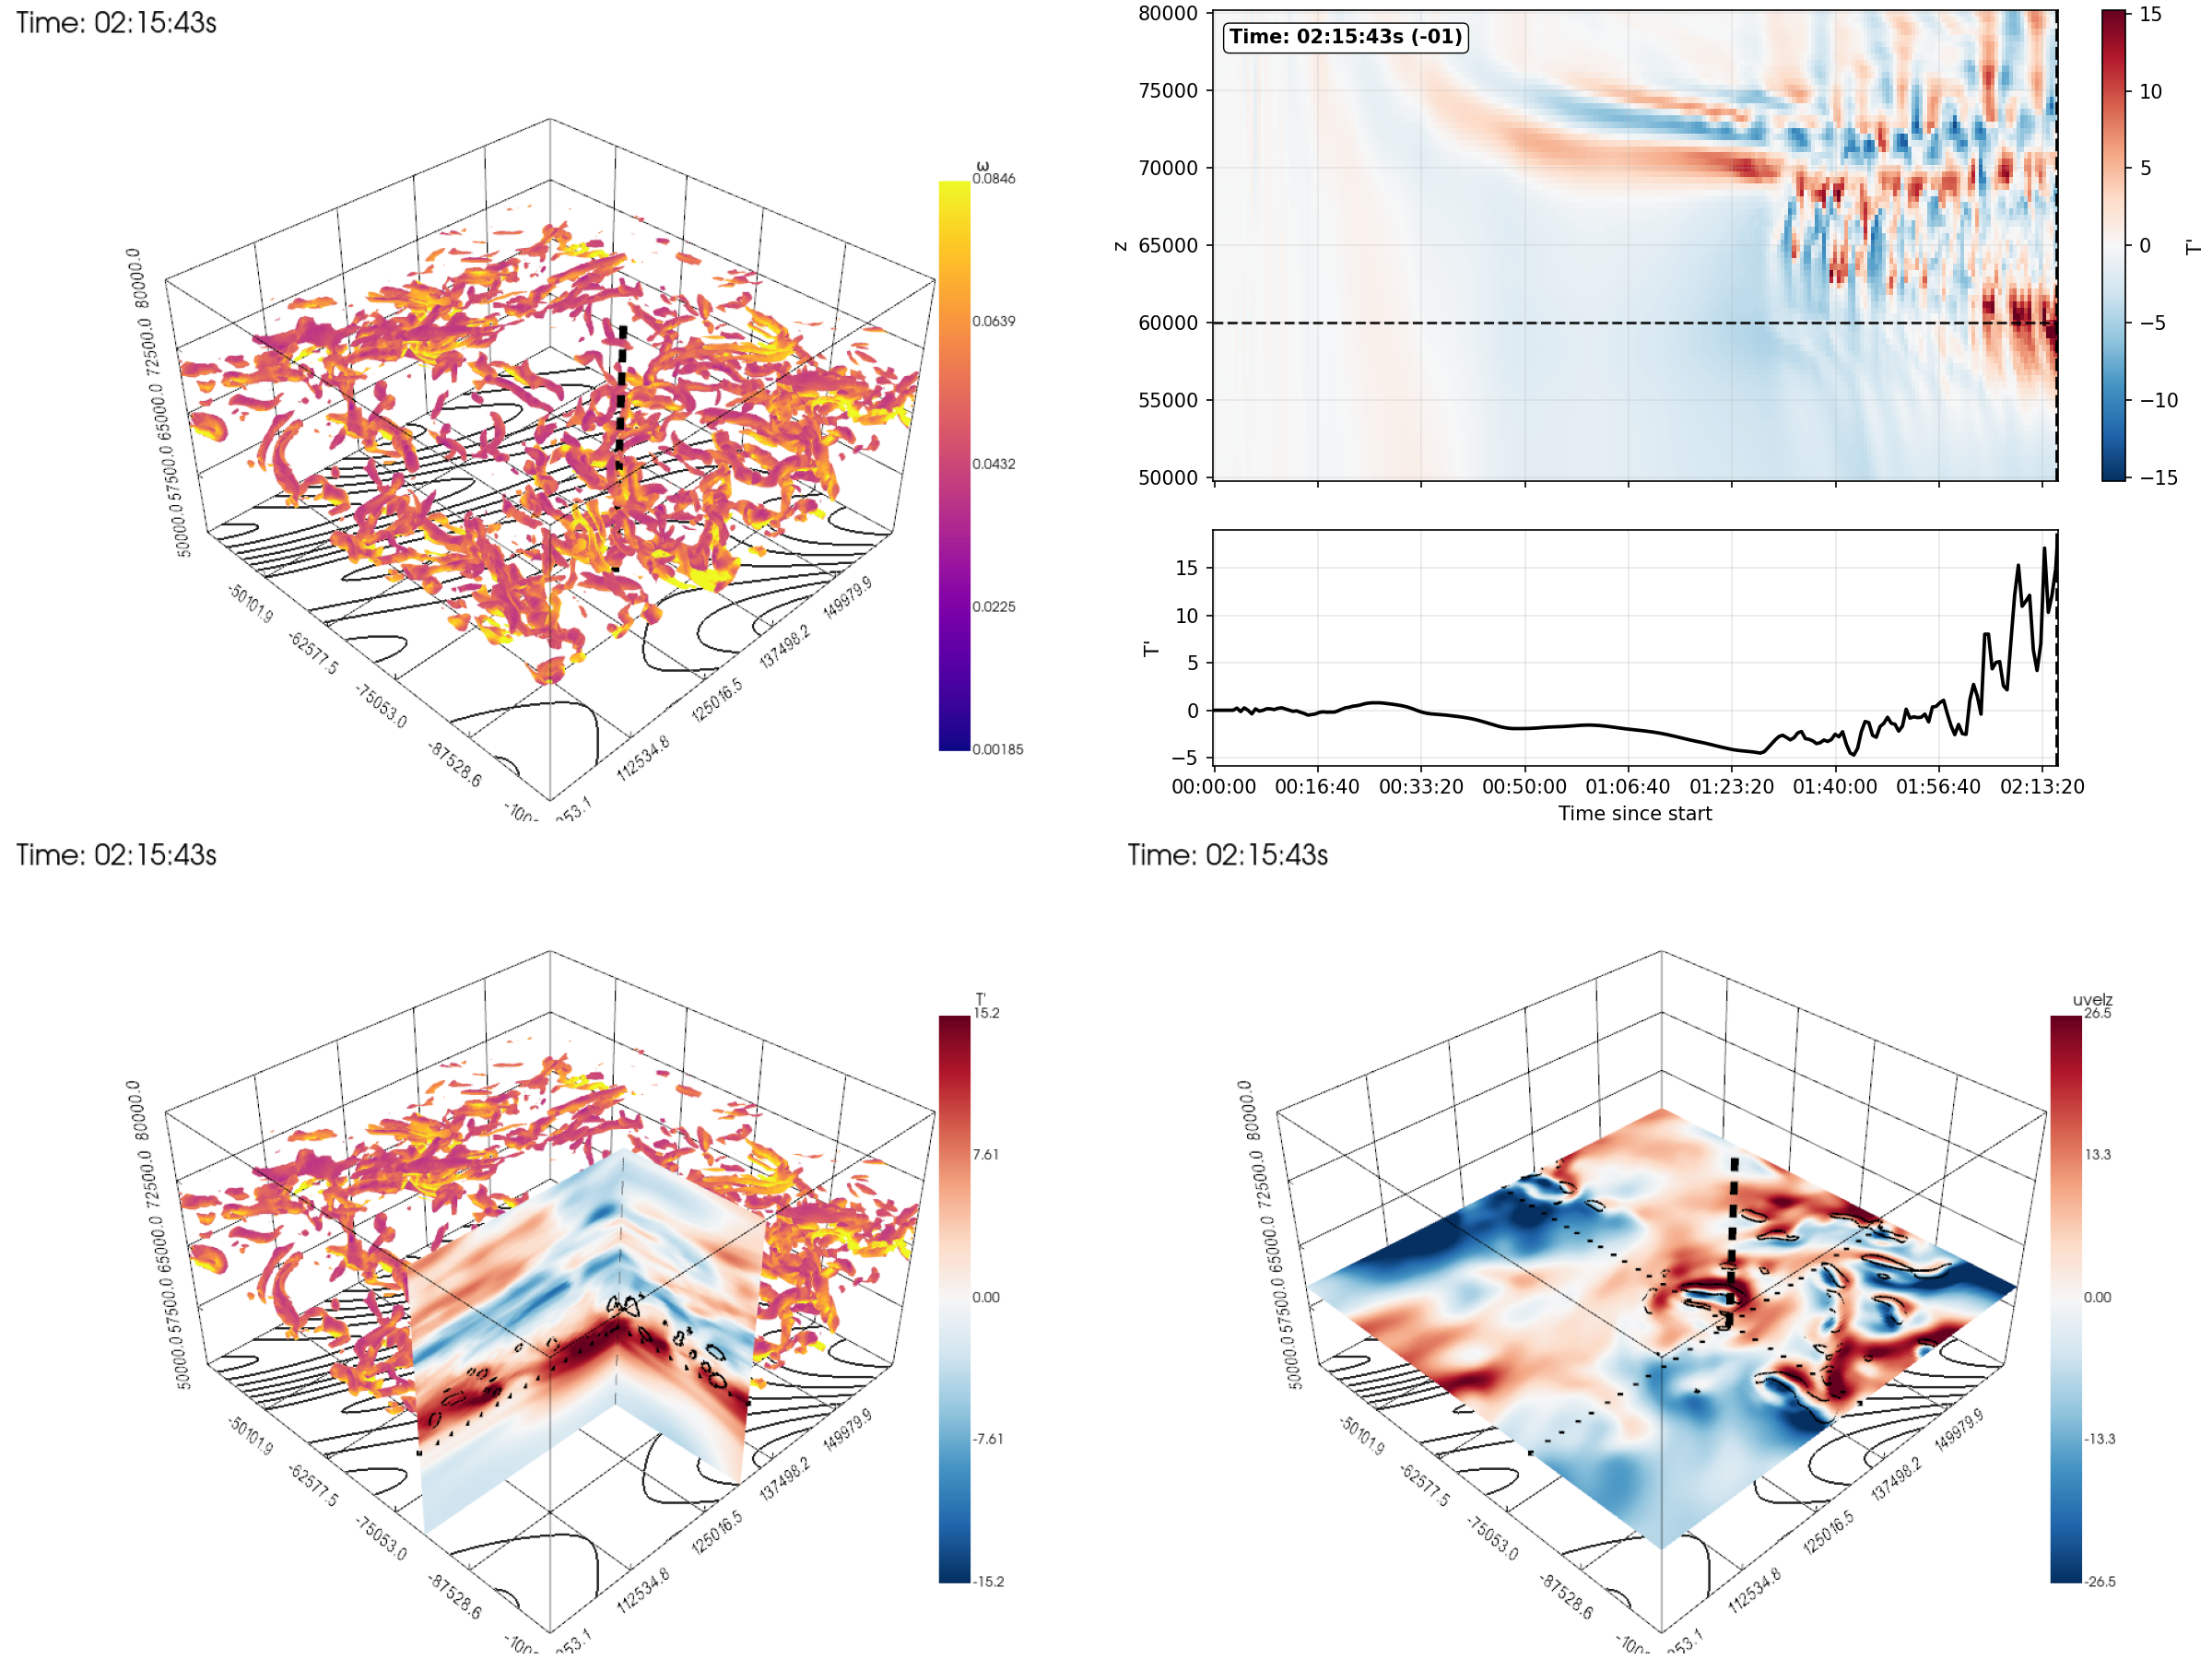

In [46]:

preview_time_index = time_index

preview_plotters = {
    "classic": pv.Plotter(off_screen=True, window_size=window_size_3d),
    "xz_slice": pv.Plotter(off_screen=True, window_size=window_size_3d),
    "xy_slice": pv.Plotter(off_screen=True, window_size=window_size_3d),
}
for _pl in preview_plotters.values():
    _pl.set_background(background)

combined_preview = render_combined_frame(
    plotters=preview_plotters,
    ds=ds,
    time_index=preview_time_index,
    lambda2_level=lambda2_level,
    vorticity_clim=vorticity_clim,
    tprime_clim=tprime_clim,
    w_clim=w_clim,
    bottom_w_contour_levels=bottom_w_contour_levels,
    times_lidar=times_lidar,
    z_lidar=z_lidar,
    tprime_curtain=tprime_curtain,
    camera_position=camera_position_for_animation,
    lidar_x_val=lidar_x_val,
    lidar_y_val=lidar_y_val,
    selected_altitude_value=timeseries_altitude_value_used,
    figure_size=combined_figure_size,
    dpi=combined_dpi,
)

for _pl in preview_plotters.values():
    _pl.close()

Image.fromarray(combined_preview)


## Save combined JPG frames and build an animation

In [ ]:

frames_dir = clear_frame_directory(Path(frames_dirname))
time_indices = list(range(ds.sizes[time_name]))
outfile = Path(f"{animation_basename}.{animation_format.lower()}")

worker_config = {
    "nc_path": str(nc_path),
    "ds": ds,
    "frames_dir": str(frames_dir),
    "window_size_3d": tuple(window_size_3d),
    "background": background,
    "lambda2_level": float(lambda2_level),
    "vorticity_clim": tuple(vorticity_clim),
    "tprime_clim": tuple(tprime_clim),
    "w_clim": tuple(w_clim),
    "bottom_w_contour_levels": np.asarray(bottom_w_contour_levels, dtype=float),
    "times_lidar": np.asarray(times_lidar),
    "z_lidar": np.asarray(z_lidar),
    "tprime_curtain": np.asarray(tprime_curtain),
    "camera_position": camera_position_for_animation,
    "lidar_x_val": None if lidar_x_val is None else float(lidar_x_val),
    "lidar_y_val": None if lidar_y_val is None else float(lidar_y_val),
    "selected_altitude_value": float(timeseries_altitude_value_used),
    "figure_size": tuple(combined_figure_size),
    "dpi": int(combined_dpi),
}

if parallel_frame_generation and len(time_indices) > 1:
    render_frames_parallel(time_indices, worker_config, ncpus=animation_ncpus)
else:
    render_frames_serial(time_indices, worker_config)

if animation_format.lower() == "mp4":
    outfile = build_mp4_from_pngs(frames_dir, outfile, fps=fps)
elif animation_format.lower() == "gif":
    with imageio.get_writer(str(outfile), mode="I", fps=fps) as writer:
        for ti in time_indices:
            png_path = frame_png_path(frames_dir, ti)
            writer.append_data(imageio.imread(png_path))
else:
    raise ValueError("animation_format must be 'gif' or 'mp4'.")

print(f"Saved animation to {outfile.resolve()}")
print(f"Saved PNG frames to {frames_dir.resolve()}")


[i]  CPUs available: 256
[i]  CPUs for rendering: 227


malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_consolidate(): unaligned fastbin chunk detected
malloc_con


## Notes

- The notebook uses **one λ₂ isosurface** only in the **upper-left classic 3D panel**.
- The **lower-left XZ slice** is taken at the **same `y` location as the virtual lidar** and is colored by **$T'$**.
- The **lower-right XY slice** is taken at the **selected altitude** and is colored by **vertical wind `w`**.
- The **lower panels** do **not** show the isosurface; they only show the slice plus the **λ₂ contour-line overlay**.
- The **black dashed vertical line** in each 3D panel marks the virtual-lidar location `(x, y)`.
- The **bottom-plane contour lines** in all 3D panels are contours of **`w` at the lowest model level**.
- The notebook computes temperature from
  \[
  T = \theta_{\mathrm{total}}\, \Pi_{\mathrm{total}}
  \]
  and then forms
  \[
  T' = T - \langle T \rangle_{x,y}
  \]
  at each time and level.
- If the thermodynamic consistency check shows unexpectedly large differences between the Poisson-based and ideal-gas-based temperatures, inspect the definition and units of `exner_total` in your model output.
